In [2]:
# import libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.datasets import cifar10 #canadian institute for advanced research

In [3]:
#load the dataset
(ip_train, op_train), (ip_test, op_test) = cifar10.load_data()
print("Training data shape: ", ip_train.shape, op_train.shape)
print("Test data shape: ", ip_test.shape, op_test.shape)    


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 96s 1us/step
Training data shape:  (50000, 32, 32, 3) (50000, 1)
Test data shape:  (10000, 32, 32, 3) (10000, 1)


In [4]:
    #reshaping the input data to include channel dimension
ip_train = ip_train.reshape((ip_train.shape[0], 32, 32, 3))
ip_test = ip_test.reshape((ip_test.shape[0], 32, 32, 3))
print("Training data shape after reshaping: ", ip_train.shape)
print("Test data shape after reshaping: ", ip_test.shape)   

Training data shape after reshaping:  (50000, 32, 32, 3)
Test data shape after reshaping:  (10000, 32, 32, 3)


In [5]:
#prepare the data 
ip_train =ip_train.astype('float32') / 255.0
ip_test = ip_test.astype('float32') / 255.0

In [6]:
#build the convolutional neural network model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/Users/sita/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#add the final dense layers, dropout layer and output layer
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))


In [8]:
#compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
#view the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#train the model
model.fit(ip_train, op_train, epochs=10, batch_size=64, validation_data=(ip_test, op_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2617 - loss: 1.9578 - val_accuracy: 0.4858 - val_loss: 1.4228
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4789 - loss: 1.4440 - val_accuracy: 0.5677 - val_loss: 1.2270
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5427 - loss: 1.2756 - val_accuracy: 0.6176 - val_loss: 1.0866
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5828 - loss: 1.1873 - val_accuracy: 0.6506 - val_loss: 1.0025
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6157 - loss: 1.1061 - val_accuracy: 0.6550 - val_loss: 0.9792
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6369 - loss: 1.0314 - val_accuracy: 0.6765 - val_loss: 0.9532
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6537 - loss: 0.9878 - val_accuracy: 0.6806 - val_loss: 0.9244
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6715 - loss: 0.9474 - val_accuracy: 0

In [11]:
#test the model
model.evaluate(ip_test, op_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7058 - loss: 0.8699


[0.8675979375839233, 0.7031999826431274]

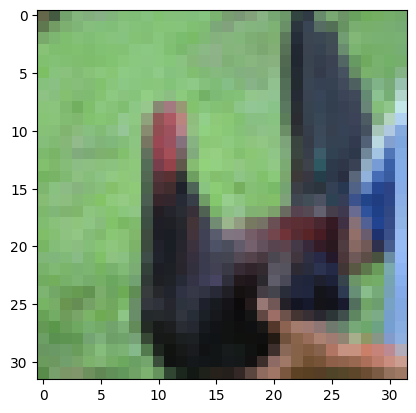

In [26]:
#carry out inference/predictions
import matplotlib.pyplot as plt
%matplotlib inline

test_image = ip_test[25]
plt.imshow(test_image.reshape(32,32,3))

In [27]:
#test the image 
import numpy as np
from tensorflow.keras.preprocessing import image

#convert the test image to array and reshape it to include batch dimension
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
test_image_array = image.img_to_array(test_image)
test_image =test_image_array.reshape((1, 32, 32, 3))

In [28]:
#round off results and find max value among them
result = model.predict(test_image)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


array([[0.00955458, 0.00180116, 0.22606851, 0.15533721, 0.23557949,
        0.05958819, 0.28273576, 0.01294163, 0.00298593, 0.01340751]],
      dtype=float32)

In [29]:
np.around(result)
n = (np.around(result))
n

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [30]:
nMax = np.argmax(n)
print("Predicted class is: ", classes[nMax])

Predicted class is:  airplane
